In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

REFORM_COLOR = '#12239E'
ACCENT_COLOR = '#E8102A'

In [2]:
df = pd.read_csv('../../data/processed/model_data.csv')

df['log_population_density'] = np.log1p(df['population_density'])
df['log_foreign_born_pct']   = np.log1p(df['foreign_born_pct'])

FEATURES = ['leave_vote_share', 'degree_pct', 'median_age', 'median_weekly_wage',
            'claimant_rate', 'log_foreign_born_pct', 'log_population_density',
            'ethnic_minority_pct', 'deprivation_score', 'is_scotland']

feature_labels = {
    'leave_vote_share':'Brexit Leave vote',
    'degree_pct':'Degree holders',
    'median_age':'Median age',
    'median_weekly_wage':'Median weekly wage',
    'claimant_rate':'Claimant rate',
    'log_foreign_born_pct':'Foreign-born (log)',
    'log_population_density':'Population density (log)',
    'ethnic_minority_pct':'Ethnic minority',
    'deprivation_score':'Deprivation score',
    'is_scotland':'Scotland',
}

X = df[FEATURES]
y = df['reform_vote_share']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# champion
lasso = Lasso(alpha=0.001, max_iter=10000).fit(X_train_sc, y_train)

# challengers - best params from notebook 02
rf = RandomForestRegressor(n_estimators=300, max_depth=None,
                           min_samples_leaf=3, random_state=42).fit(X_train, y_train)
gb = GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.05,
                               min_samples_leaf=5, random_state=42).fit(X_train, y_train)

print("models trained")

models trained


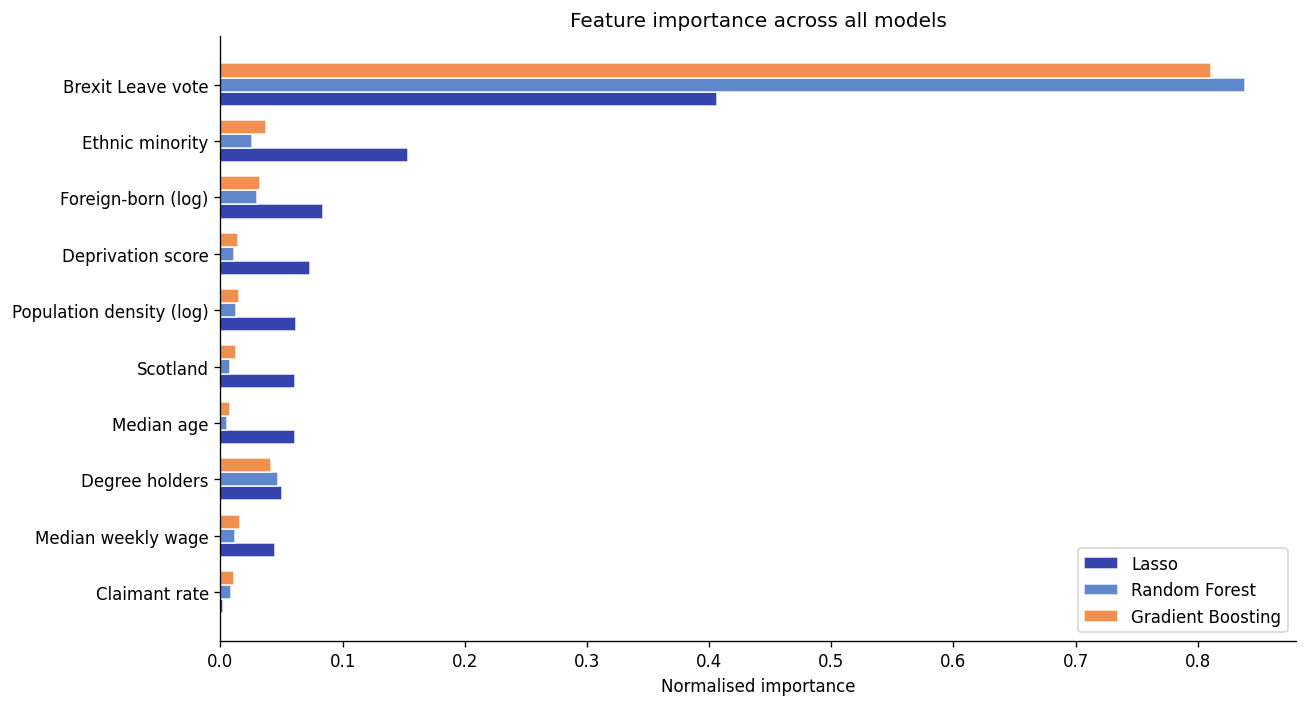

In [3]:
def normalise(s):
    return s / s.sum()

lasso_imp = pd.Series(np.abs(lasso.coef_), index=FEATURES)
rf_imp = pd.Series(rf.feature_importances_, index=FEATURES)
gb_imp = pd.Series(gb.feature_importances_, index=FEATURES)

importance_df = pd.DataFrame({
    'Lasso': normalise(lasso_imp),
    'Random Forest': normalise(rf_imp),
    'Gradient Boosting':normalise(gb_imp),
}, index=FEATURES)

importance_df.index = [feature_labels[i] for i in importance_df.index]
importance_df = importance_df.sort_values('Lasso', ascending=True)

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(importance_df))
w = 0.25
colors = [REFORM_COLOR, '#4472C4', '#ED7D31']

for i, (col, color) in enumerate(zip(importance_df.columns, colors)):
    ax.barh(x + i*w, importance_df[col], w,
            label=col, color=color, alpha=0.85, edgecolor='white')

ax.set_yticks(x + w)
ax.set_yticklabels(importance_df.index)
ax.set_xlabel("Normalised importance")
ax.set_title("Feature importance across all models")
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig('../../outputs/results_01_feature_importance.png', bbox_inches='tight')
plt.show()

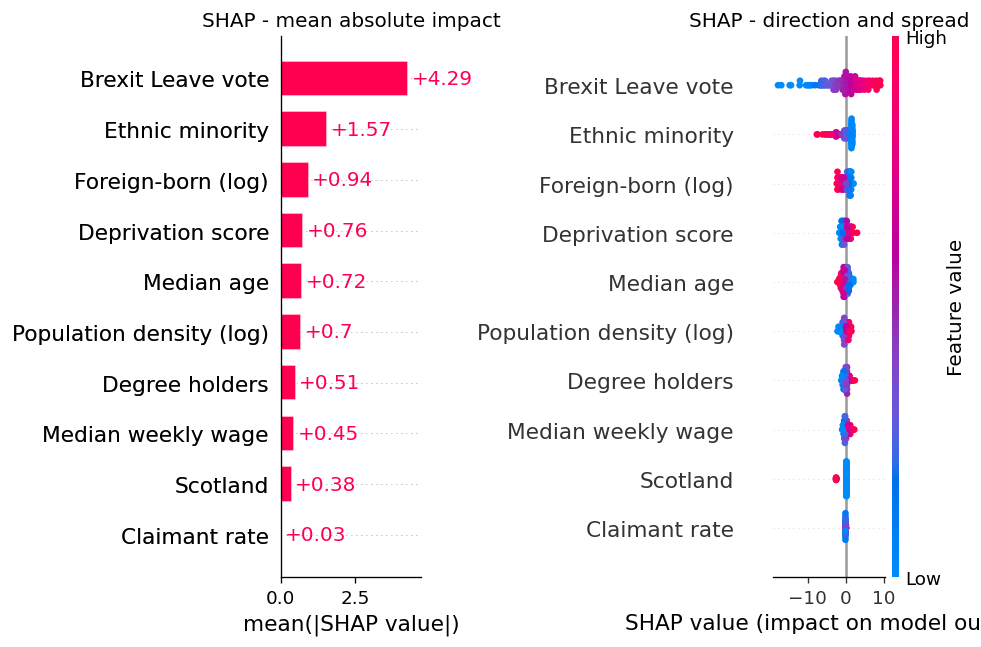

In [ ]:
# SHAP on Lasso 
lasso_unscaled = Lasso(alpha=0.001, max_iter=10000).fit(X_train, y_train)

explainer = shap.LinearExplainer(lasso_unscaled, X_train)
shap_values = explainer(X_test)

# rename features for display
shap_values.feature_names = [feature_labels[f] for f in FEATURES]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plt.sca(axes[0])
shap.plots.bar(shap_values, max_display=10, show=False)
axes[0].set_title("SHAP - mean absolute impact")

plt.sca(axes[1])
shap.plots.beeswarm(shap_values, max_display=10, show=False)
axes[1].set_title("SHAP - direction and spread")

plt.tight_layout()
plt.savefig('../../outputs/results_02_shap.png', bbox_inches='tight')
plt.show()

## Results - data science perspective

Lasso achieves CV R2 = 0.843 with a near-zero overfitting gap (-0.003), confirming strong
out-of-sample performance. The model predicts Reform UK vote share within 1.86 percentage
points on average (MAE), which is a good result given the noise in constituency-level political data.

The three challengers each reveal a different limitation. Linear Regression on the VIF-reduced feature set
achieves CV R2 = 0.730, showing that manually dropping collinear features led to a meaningful loss of information. Random
Forest achieved the highest test R2 (0.881) but showed an overfitting gap of 0.029, more than twice
Gradient Boosting's gap of 0.012, illustrating the risk of more complex ensemble methods on a
607-observation dataset. Gradient Boosting came closest to Lasso on CV (0.849 vs 0.843)
but the improvement was too small to justify the additional complexity.

To further isolate the contribution of Brexit vote share, we run a second Lasso model
excluding leave_vote_share but keeping all other features. This model achieves CV R2 of 0.751,
meaning demographic variables alone explain around 75% of the geographic variation in Reform
support. Brexit vote share variable adds 9.2 percentage points. This is consistent with the VIF
finding that leave_vote_share is collinear with the demographic variables.

The SHAP analysis confirms the coefficient ranking. Brexit Leave vote share dominates, followed
by ethnic minority share and education. The Scotland indicator had a clear negative effect, consistent 
with the descriptive finding that Reform UK performed substantially worse in Scottish constituencies. By contrast, 
the claimant rate had almost no impact in the SHAP analysis, reinforcing the conclusion that unemployment does not 
independently explain Reform UK support.

## Results - business and political perspective

The results suggest that Reform UK’s 2024 vote share is closely linked to the geography of the 2016 Brexit vote. 
Constituencies that voted strongly to Leave were also much more likely to support Reform UK, indicating substantial 
continuity between the Brexit electorate and Reform’s current voter base. 
However, when we run the model without leave_vote_share,
it still achieves CV R2 = 0.751, meaning that demographic variables alone explain around
75% of the geographic variation in Reform support. 

Education is the second most important predictor after Brexit vote. Lower degree share
consistently predicts higher Reform support, a pattern seen across populist parties in
Europe. Contrary to the narrative that Reform voters are economically desperate, median
weekly wage has weak predictive power compared to education, and the claimant rate
(r = -0.08, p = 0.060) is marginally non-significant. Reform voters appear to be
working-class but employed, concentrated in post-industrial towns rather than the most
economically deprived urban areas.

Scotland required its own indicator variable. Even controlling for demographics and Brexit
vote share, Scottish constituencies vote Reform at systematically lower levels. One possible 
explanation is that anti-establishment sentiment in Scotland is more strongly captured by the SNP than by Reform UK.

The VIF analysis revealed that leave_vote_share is collinear with the demographic
variables; it gets dropped by iterative VIF reduction before any other feature. This
could mean that the 2016 Brexit vote is not fully independent of constituency structure; areas that
were already low-education, high-deprivation and ethnically homogeneous were always likely
to vote to leave and are now likely to vote Reform. 

## Conclusion

This project examined whether demographic, economic and political variables can explain differences 
in Reform UK vote share across UK constituencies.

Results show that Reform UK support is strongly predictable (CV R2 = 0.843) from socio-demographic and
political variables. The 2016 Brexit Leave vote is the single strongest predictor, but the
VIF analysis shows it is not independent, it is partly a function of the same demographic
structure that drives Reform support directly. Education, ethnic composition, deprivation
and the Scotland indicator also played important roles in explaining variation across constituencies.

Lasso was selected as champion because the underlying relationship is largely linear,
confirmed by near-linear scatterplots and the small CV gap between Lasso and the best
ensemble method (0.006). On a dataset of 607 constituencies, adding non-linear complexity
does not justify the trade-off in interpretability.

Several limitations should be noted. The analysis is based on constituency-level data and therefore 
cannot identify which individuals voted for Reform UK. Constituencies where Reform UK did not field 
a candidate were excluded, which may introduce selection bias. In addition, the dataset does not 
capture some local factors such as candidate quality or campaign intensity.